# SFML Project
## Comparing Machine Learning Algorithms for Classification and Regression

**Group members:**  
- MARYAM LACHHAB —  Master of Applied Informatics: Artificial intelligence and Data Science
- EMMA CROISEZ — Master of Physics: Research focus 
- DENIS YUSUFOV — Master of Physics: Research Focus

## 1. Introduction

in this project we ...

## 2. Research Questions

The project is organized around the following research questions:

1. How does noise affect classification performance?
2. 
3. What is the impact of class imbalance on the performance?

These questions are relevant because they help us understand both the predictive power and the limitations of machine learning models under different conditions.

# imports #####################################

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor

## 3. Datasets

We use two types of datasets in this project:

- A **synthetic dataset**, which allows us to control properties such as overlap and noise.
- A **real-world dataset**, which allows us to test the algorithms in a more realistic setting.



# Research Question 1

### How does noise affect classification performance?

This question is motivated by prior experience with X-ray image data, where model performance was negatively affected by noise and limited data.

To keep the analysis simple and interpretable, we do not use image data or convolutional neural networks. Instead, we use a synthetic dataset, which allows us to control the level of noise and clearly visualize its impact on classification performance.


In [2]:

# synthetic datatset 
##################1️⃣RESEARCH Q11️⃣##########################
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=500,#500 examples 
    centers=2,#2 classes (broken , not broken bones)
    cluster_std=5.0,#noise (1 low noise , 5 high noise )
    random_state=42#
)

In [3]:
#real world datatset

# explain the dataset 

## 4. Data Preprocessing

Before training the models, we split the datasets into training and test sets. For some algorithms, we also standardize the features because they are sensitive to scale.

In [4]:
##################1️⃣RESEARCH Q11️⃣##########################
# Split the dataset into training and testing data
# 80% of the data will be used to train the models
# 20% will be used to test how well the models perform on unseen data

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Feature values (input data)
    y,                  # Class labels (target values)
    test_size=0.2,      # 20% of the data goes to the test set
    random_state=42     # Ensures reproducible results
)

# Create a StandardScaler object
# Standardization rescales the features so they have:
# mean = 0 and standard deviation = 1

scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# The scaler learns the statistics from the training set only

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test data


X_test_scaled = scaler.transform(X_test)

## 5. Machine Learning Models

For the classification task, we use:
- 
- 

For the regression task, we use:
- 
- 

These models were chosen because ...

In [5]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create the Logistic Regression model

log_reg = LogisticRegression()

# Train the model using the training data

log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

In [6]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create the Support Vector Machine model

svm_model = SVC()

# Train the SVM model

svm_model.fit(X_train_scaled, y_train)

SVC()

In [7]:
##################1️⃣RESEARCH Q11️⃣##########################
# Predict class labels using Logistic Regression

log_reg_predictions = log_reg.predict(X_test_scaled)

# Predict class labels using SVM

svm_predictions = svm_model.predict(X_test_scaled)

In [8]:
##################1️⃣RESEARCH Q11️⃣##########################
# Calculate Logistic Regression accuracy

log_reg_accuracy = accuracy_score(
    y_test,
    log_reg_predictions
)

# Calculate SVM accuracy

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

# Print results

print("Logistic Regression Accuracy:", log_reg_accuracy)
print("SVM Accuracy:", svm_accuracy)

Logistic Regression Accuracy: 0.9
SVM Accuracy: 0.92


# interpretation 

# visualization

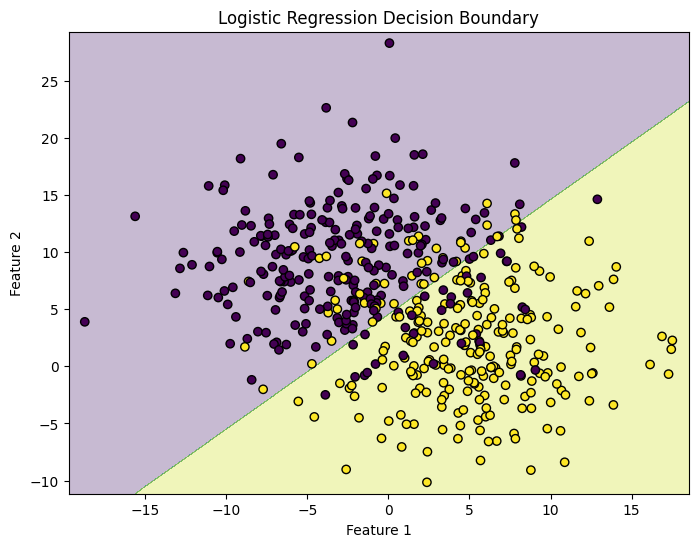

In [9]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create a mesh grid for plotting

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict values across the grid

Z = log_reg.predict(
    scaler.transform(
        np.c_[xx.ravel(), yy.ravel()]
    )
)

# Reshape predictions to match grid

Z = Z.reshape(xx.shape)

# Plot decision boundary

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot original data points

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='k'
)

plt.title("Logistic Regression Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

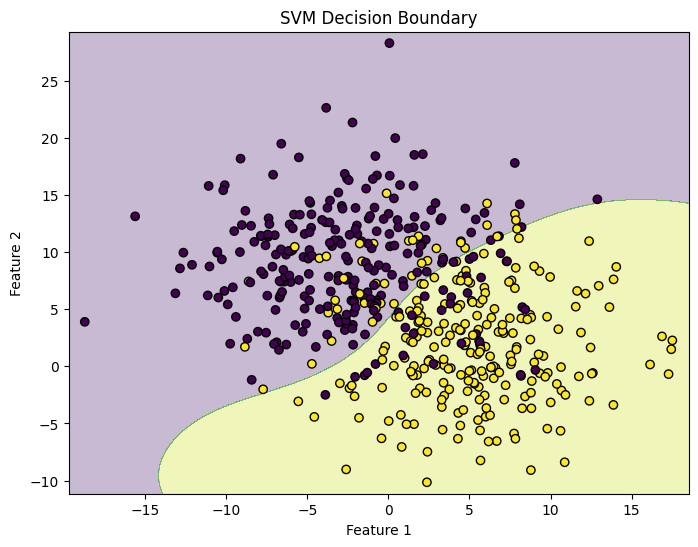

In [10]:
##################1️⃣RESEARCH Q11️⃣##########################
# Predict values across the grid

Z = svm_model.predict(
    scaler.transform(
        np.c_[xx.ravel(), yy.ravel()]
    )
)

# Reshape predictions

Z = Z.reshape(xx.shape)

# Plot decision boundary

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='k'
)

plt.title("SVM Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Research question 2 : In the case of SVM, what is the impact of class overlap, class imbalance, and mislabeled data on the number, fraction and location of support vectors?

## 1. Introduction :

In this report, we will use a synthetic dataset to show how class overlap, class imbalance and mislabeled data vary the number , fraction and location of support vectors in the case of a soft margin SVM. We will start by introducing the concepts of support vector machine and the need of the soft-margin. Then, we will present the methodology and the code used to create and control the dataset on which we will apply our machine learning algorithm. Finally, we will present our result and discuss them.

## 2. Soft-margin Support Vector Machine (SVM) description :

### 2.1 Training set and notation

Let

$$
\mathcal{D}=\{(\mathbf{x}_n,y_n)\}_{n=1}^{N}
$$

be a binary classification training set, where:

- $N$ is the number of training examples.
- $\mathbf{x}_n \in \mathbb{R}^{d}$ is the feature vector of example $n$.
- $d$ is the number of real-valued input features.
- $y_n \in \{-1,+1\}$ is the class label of example $n$.

The goal is to learn a classification rule that predicts whether a new point $\mathbf{x}$ belongs to class $+1$ or class $-1$.

### 2.2 Linear classifier and decision boundary

A linear SVM searches for a classifier of the form

$$
g(\mathbf{x}) = \operatorname{sign}(\mathbf{w}^{T}\mathbf{x}+b),
$$

where $\mathbf{w}\in\mathbb{R}^{d}$ is the weight vector, $b\in\mathbb{R}$ is the bias or intercept term, $\mathbf{w}^{T}\mathbf{x}$ is the dot product, and $\operatorname{sign}(z)$ returns $+1$ if $z\ge 0$ and $-1$ otherwise.

The set of points satisfying

$$
\mathbf{w}^{T}\mathbf{x}+b=0
$$

is a hyperplane. This hyperplane is the decision boundary. The vector $\mathbf{w}$ is orthogonal to the decision boundary, and $b$ shifts the hyperplane away from the origin.

### 2.3 Functional margin and geometric margin

For a training example $(\mathbf{x}_n,y_n)$, define the score

$$
f(\mathbf{x}_n)=\mathbf{w}^{T}\mathbf{x}_n+b.
$$

The prediction is correct when $y_n f(\mathbf{x}_n)>0$. The quantity

$$
y_n(\mathbf{w}^{T}\mathbf{x}_n+b)
$$

is called the **functional margin**. It is positive if the example is correctly classified and negative if the example is misclassified.

The distance from $\mathbf{x}_n$ to the hyperplane is

$$
\frac{|\mathbf{w}^{T}\mathbf{x}_n+b|}{\|\mathbf{w}\|},
$$

where $\|\mathbf{w}\|=\sqrt{w_1^2+\cdots+w_d^2}$ is the Euclidean norm. The signed geometric margin is

$$
\frac{y_n(\mathbf{w}^{T}\mathbf{x}_n+b)}{\|\mathbf{w}\|}.
$$

## 2.4 Hard-margin SVM

If the training set is linearly separable, there exists a hyperplane that classifies every training example correctly. The hard-margin SVM chooses the separating hyperplane with the largest margin.

The hard-margin constraints are

$$
y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1, \qquad n=1,\ldots,N.
$$

The margin width is $2/\|\mathbf{w}\|$. Thus, maximizing the margin is equivalent to minimizing $\|\mathbf{w}\|^2$:

$$
\begin{aligned}
\min_{\mathbf{w},b} \quad & \frac{1}{2}\|\mathbf{w}\|^2 \\
\text{subject to} \quad & y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1, \qquad n=1,\ldots,N.
\end{aligned}
$$

The factor $1/2$ is included for mathematical convenience and does not change the minimizer.

### 2.5 Why soft margin is needed

In many real data sets, the training examples are not perfectly linearly separable. This can happen because of noise, overlapping classes, outliers, or insufficient features.

The **soft-margin SVM** allows some examples to violate the hard-margin constraints. It still tries to find a large-margin hyperplane, but it also penalizes violations of the margin.

### 2.6 Slack variables

Soft-margin SVM introduces a slack variable $\xi_n$ for each training example.

The soft-margin constraints are

$$
y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1-\xi_n, \qquad n=1,\ldots,N,
$$

with

$$
\xi_n\ge 0, \qquad n=1,\ldots,N.
$$

The slack variable $\xi_n$ measures how much example $n$ violates the margin constraint:

- $\xi_n=0$: the point is correctly classified and lies on or outside the margin.
- $0<\xi_n<1$: the point is correctly classified but lies inside the margin.
- $\xi_n=1$: the point lies exactly on the decision boundary.
- $\xi_n>1$: the point is misclassified.

### 2.7 Primal optimization problem

The soft-margin SVM solves

$$
\begin{aligned}
\min_{\mathbf{w},b,\boldsymbol{\xi}} \quad
& \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{n=1}^{N}\xi_n \\
\text{subject to} \quad
& y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1-\xi_n, \qquad n=1,\ldots,N, \\
& \xi_n\ge 0, \qquad n=1,\ldots,N.
\end{aligned}
$$

Here $\boldsymbol{\xi}=(\xi_1,\ldots,\xi_N)$ is the vector of slack variables and $C>0$ is a regularization parameter chosen by the user. The term $\frac{1}{2}\|\mathbf{w}\|^2$ encourages a large margin. The term $\sum_{n=1}^{N}\xi_n$ penalizes margin violations.

Large $C$ makes violations expensive, so the algorithm tries harder to classify training points correctly. Small $C$ makes violations less expensive, allowing a wider margin and possibly more training errors. In practice, $C$ is selected using a validation set or cross-validation.

### 2.8 Hinge-loss form

The constrained soft-margin problem can also be written as

$$
\min_{\mathbf{w},b}\quad
\frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{n=1}^{N}\max\left(0,1-y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\right).
$$

The function

$$
\ell_n(\mathbf{w},b)=\max\left(0,1-y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\right)
$$

is the **hinge loss** for example $n$. It is zero when $y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1$ and positive when the point is inside the margin or misclassified.

### 2.9 Support vectors

A **support vector** is a training point that directly influences the final decision boundary.

In soft-margin SVM, support vectors are points for which the margin constraint is active or violated. These include points satisfying

$$
y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\le 1.
$$

Geometrically, support vectors lie on the margin, inside the margin, or on the wrong side of the decision boundary. Points far outside the margin have zero hinge loss and do not affect the final hyperplane once the solution is found.

## 3. Methodology :

The experiments vary one factor at a time while holding the other factors fixed:

1. **Class overlap** is controlled by `class_sep` in `sklearn.datasets.make_classification`. A smaller value means the class centers are closer and the classes overlap more.
2. **Class imbalance** is controlled by the class weights. For example, `(0.95, 0.05)` means approximately 95% of observations belong to one class and 5% to the other.
3. **Mislabeled data** is controlled by `flip_y`, the fraction of labels randomly flipped.


For each setting, the experiment is repeated over several random seeds. We report means and standard deviations of training error, test error, balanced test accuracy, total support vectors, support-vector fraction, class-specific support-vector counts, class-specific support-vector rates, and margin width.

The balanced test accuracy gives equal importance to each class, this quantity is crucial when looking at a inbalanced dataset. To have a decent balanced test accuracy, an algorithm would have to perform well on the majority dataset as well as on the minority dataset

A linear soft-margin SVM is used throughout. Features are standardized before fitting because SVMs depend on dot products and Euclidean distances which are strongly scale sensitive. Without scaling, variables with larger numerical ranges could dominate the margin.

In [11]:
# Import the needed Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [ ]:
#Global settings

# Reproducibility and experimental design
RANDOM_STATE = 42 #seed
TEST_SIZE = 0.30 #30% of the dataset used for testing 
N_REPEATS = 500 #number of time we repeat each experiment

# Baseline/default dataset parameters
BASE_N_SAMPLES = 5000
BASE_N_FEATURES = 10
BASE_CLASS_SEP = 1.5
BASE_CLASS_WEIGHTS = (0.50, 0.50)
BASE_FLIP_Y = 0.00

# Parameters to vary
CLASS_SEPARATIONS = [0.5, 0.8, 1.2, 1.8, 2.5]          # controls overlap
CLASS_WEIGHTS_LIST = [(0.50, 0.50), (0.70, 0.30), (0.85, 0.15), (0.95, 0.05)]  # imbalance
LABEL_NOISE_LIST = [0.00, 0.02, 0.05, 0.10, 0.20]      # mislabeled data

# SVM regularization. We keep it fixed to isolate data effects. In applied work, 
#C should be selected by cross-validation by testing several possible values 
#and choosing the one that gives the best performance on unseen data.
SVM_C = 1.0

### 3.1 Data generation function

The function below creates a binary classification dataset with a chosen degree of overlap, imbalance, and label noise. The labels returned by `make_classification` are $0$ and $1$ refering to the $-1$ and $+1$ from the theory above.

In [13]:
#Generate a binary classification dataset with controlled overlap, imbalance, and label noise.

def make_dataset(n_samples, n_features, class_sep, class_weights, flip_y, random_state):
    n_informative = max(2, int(np.ceil(0.6 * n_features)))
    n_redundant = int(np.floor(0.2 * n_features))

    if n_informative + n_redundant >= n_features:
        n_redundant = max(0, n_features - n_informative - 1)

    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=n_redundant,
        n_repeated=0,
        n_classes=2,
        n_clusters_per_class=1,
        weights=list(class_weights),
        flip_y=flip_y,
        class_sep=class_sep,
        random_state=random_state
    )

    return np.asarray(X), np.asarray(y)

### 3.2 Model definition

The model is a pipeline containing two operations: standardization of each feature to mean zero and variance one, followed by fitting a linear soft-margin SVM. The linear kernel is chosen because the purpose of the report is to study the geometry of margins and support vectors in an interpretable setting.

In [14]:
#Build the model, soft-margin linear SVM with scaling
def build_linear_svm(C=1.0):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=C))
    ])


#misclassification rate = 1 - accuracy
def classification_error(y_true, y_pred):
    return 1.0 - accuracy_score(np.asarray(y_true), np.asarray(y_pred))

### 3.3 Fitting one SVM and extracting scientific quantities

For each fitted model, we extract both performance and the studied quantities. The latter are :

- `n_support_total`: total number of support vectors;
- `support_fraction`: fraction of training points that are support vectors;
- `n_support_class_0` and `n_support_class_1`: support vectors by class;
- `support_rate_class_0` and `support_rate_class_1`: fraction of each class that becomes support vectors;
- `margin_width`: $2/\|\mathbf{w}\|$ for a linear SVM in standardized feature space.

In [15]:
def fit_and_extract_metrics(X_train, X_test, y_train, y_test, C=1.0):
    model = build_linear_svm(C=C)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train) #prediction of the model on the training set
    y_test_pred = model.predict(X_test) #prediction of the model on the testing set

    svm = model.named_steps["svm"]
    support_vectors = svm.support_vectors_
    n_support_total = len(svm.support_vectors_)
    support_per_class = svm.n_support_

    class_counts = np.bincount(y_train, minlength=2)
    support_rate_class_0 = support_per_class[0] / class_counts[0]
    support_rate_class_1 = support_per_class[1] / class_counts[1]

    w = svm.coef_.ravel()
    w_norm = np.linalg.norm(w)
    margin_width = np.nan if w_norm == 0 else 2.0 / w_norm

    if w_norm == 0:
        support_distances = np.full(len(support_vectors), np.nan)
    else:
        support_distances = np.abs(svm.decision_function(support_vectors)) / w_norm

    mean_support_distance = np.nanmean(support_distances)

    return {
        "train_error": classification_error(y_train, y_train_pred),
        "test_error": classification_error(y_test, y_test_pred),
        "balanced_test_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "n_support_total": n_support_total,
        "n_support_class_0": int(support_per_class[0]),
        "n_support_class_1": int(support_per_class[1]),
        "support_rate_class_0": support_rate_class_0,
        "support_rate_class_1": support_rate_class_1,
        "support_fraction": n_support_total / len(X_train),
        "margin_width": margin_width,
        "mean_support_distance": mean_support_distance,
        "class_0_count_train": int(class_counts[0]),
        "class_1_count_train": int(class_counts[1])
    }

### 3.4 Repeated experiments

The next functions run the one-factor-at-a-time experiments. A stratified train-test split is used so that the class proportions in the training and test sets remain close to those of the full dataset.

In [16]:
#Run one experiment for one value of one controlled factor.
def run_single_experiment(setting_type, setting_value, seed):
    if setting_type == "overlap":
        class_sep = setting_value
        class_weights = BASE_CLASS_WEIGHTS
        flip_y = BASE_FLIP_Y
        setting_label = f"class_sep={setting_value:.2f}"

    elif setting_type == "imbalance":
        class_sep = BASE_CLASS_SEP
        class_weights = setting_value
        flip_y = BASE_FLIP_Y
        setting_label = f"{int(setting_value[0]*100)}/{int(setting_value[1]*100)}"

    elif setting_type == "label_noise":
        class_sep = BASE_CLASS_SEP
        class_weights = BASE_CLASS_WEIGHTS
        flip_y = setting_value
        setting_label = f"flip_y={setting_value:.2f}"

    else:
        raise ValueError("setting_type must be overlap, imbalance, or label_noise")

    X, y = make_dataset(
        n_samples=BASE_N_SAMPLES,
        n_features=BASE_N_FEATURES,
        class_sep=class_sep,
        class_weights=class_weights,
        flip_y=flip_y,
        random_state=seed
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y, #Preserves class proportions in both sets
        random_state=seed
    )

    metrics = fit_and_extract_metrics(X_train, X_test, y_train, y_test, C=SVM_C)

    row = {
        "setting_type": setting_type,
        "setting_value": setting_value,
        "setting_label": setting_label,
        "seed": seed,
        **metrics, #add all of the metrics values from the function above
    }
    return row

In [17]:
#run all experiments
def run_repeated_experiments():
    rows = []

    for value in CLASS_SEPARATIONS:
        for repeat in range(N_REPEATS):
            rows.append(run_single_experiment("overlap", value, RANDOM_STATE + repeat))

    for value in CLASS_WEIGHTS_LIST:
        for repeat in range(N_REPEATS):
            rows.append(run_single_experiment("imbalance", value, RANDOM_STATE + repeat))

    for value in LABEL_NOISE_LIST:
        for repeat in range(N_REPEATS):
            rows.append(run_single_experiment("label_noise", value, RANDOM_STATE + repeat))

    return pd.DataFrame(rows)

In [18]:
#compute means and standard deviations over repeated experiments
def summarize_results(df):
    summary = (
        df.groupby(["setting_type", "setting_label"]) #ensure that metrics are average separately for each condition
          .agg(
              mean_train_error=("train_error", "mean"),
              std_train_error=("train_error", "std"),

              mean_test_error=("test_error", "mean"),
              std_test_error=("test_error", "std"),

              mean_balanced_test_accuracy=("balanced_test_accuracy", "mean"),
              std_balanced_test_accuracy=("balanced_test_accuracy", "std"),

              mean_n_support_total=("n_support_total", "mean"),
              std_n_support_total=("n_support_total", "std"),

              mean_support_rate_class_0=("support_rate_class_0", "mean"),
              mean_support_rate_class_1=("support_rate_class_1", "mean"),
              std_support_rate_class_0=("support_rate_class_0", "std"),
              std_support_rate_class_1=("support_rate_class_1", "std"),

              mean_support_fraction=("support_fraction", "mean"),
              std_support_fraction=("support_fraction", "std"),

              mean_margin_width=("margin_width", "mean"),
              std_margin_width=("margin_width", "std"),

              mean_support_distance=("mean_support_distance", "mean"),
              std_support_distance=("mean_support_distance", "std")
          )
        .reset_index() #converts groups indices back into regular columns
    )
    return summary

## 4. Numerical results :

The following cell runs the full experiment and produces a summary table. The table is the numerical evidence on which the conclusions are based.

In [19]:
results = run_repeated_experiments()
summary = summarize_results(results)
summary.round(4)

,setting_type,setting_label,mean_train_error,std_train_error,mean_test_error,std_test_error,mean_balanced_test_accuracy,std_balanced_test_accuracy,mean_n_support_total,std_n_support_total,mean_support_rate_class_0,mean_support_rate_class_1,std_support_rate_class_0,std_support_rate_class_1,mean_support_fraction,std_support_fraction,mean_margin_width,std_margin_width,mean_support_distance,std_support_distance
0,imbalance,50/50,0.0183,0.0283,0.0186,0.0279,0.9814,0.0279,187.882,249.9221,0.0537,0.0537,0.0714,0.0714,0.0537,0.0714,0.6069,0.2109,0.2356,0.1145
1,imbalance,70/30,0.0153,0.0230,0.0160,0.0238,0.9790,0.0320,162.492,209.3326,0.0333,0.0771,0.0428,0.0995,0.0464,0.0598,0.6338,0.2221,0.2500,0.1206
2,imbalance,85/15,0.0102,0.0151,0.0111,0.0158,0.9721,0.0422,113.530,140.7987,0.0192,0.1073,0.0237,0.1339,0.0324,0.0402,0.7207,0.2649,0.2941,0.1455
3,imbalance,95/5,0.0048,0.0068,0.0050,0.0069,0.9588,0.0631,58.062,63.1445,0.0090,0.1615,0.0097,0.1777,0.0166,0.0180,9.4707,191.5479,4.6752,95.7591
4,label_noise,flip_y=0.00,0.0183,0.0283,0.0186,0.0279,0.9814,0.0279,187.882,249.9221,0.0537,0.0537,0.0714,0.0714,0.0537,0.0714,0.6069,0.2109,0.2356,0.1145
5,label_noise,flip_y=0.02,0.0284,0.0273,0.0287,0.0277,0.9713,0.0277,320.774,241.9274,0.0916,0.0917,0.0692,0.0690,0.0916,0.0691,0.9764,0.3035,0.4806,0.2059
6,label_noise,flip_y=0.05,0.0433,0.0264,0.0438,0.0272,0.9562,0.0272,483.864,237.6015,0.1383,0.1382,0.0680,0.0678,0.1382,0.0679,1.2024,0.3326,0.5897,0.2155
7,label_noise,flip_y=0.10,0.0683,0.0255,0.0687,0.0260,0.9313,0.0260,724.788,235.2305,0.2072,0.2070,0.0674,0.0671,0.2071,0.0672,1.4345,0.3592,0.6883,0.2212
8,label_noise,flip_y=0.20,0.1177,0.0232,0.1180,0.0244,0.8820,0.0244,1147.070,221.6865,0.3280,0.3275,0.0637,0.0631,0.3277,0.0633,1.7426,0.3860,0.8002,0.2237
9,overlap,class_sep=0.50,0.1857,0.0736,0.1867,0.0749,0.8133,0.0749,1652.950,581.5253,0.4723,0.4722,0.1662,0.1661,0.4723,0.1662,1.0506,0.4553,0.3478,0.1361


## 5. Visualization of quantitative trends :

The plots below show means over repeated random seeds. Error bars show one empirical standard deviation.

In [20]:
def plot_metric(summary_df, setting_type, y_mean_col, y_std_col, ylabel, title, second_mean_col=None,
                second_std_col=None, first_label="Class 0", second_label="Class 1"):
    subset = summary_df[summary_df["setting_type"] == setting_type].copy() #keeping only the rows corresponding to the setting type

    #we order the x-axis in logical order to prevent another unfortunate sort
    if setting_type == "overlap":
        order = [f"class_sep={v:.2f}" for v in CLASS_SEPARATIONS]
    elif setting_type == "imbalance":
        order = [f"{int(a*100)}/{int(b*100)}" for a, b in CLASS_WEIGHTS_LIST]
    elif setting_type == "label_noise":
        order = [f"flip_y={v:.2f}" for v in LABEL_NOISE_LIST]

    subset["setting_label"] = pd.Categorical(subset["setting_label"], categories=order, ordered=True) #->the order is meaningful
    subset = subset.sort_values("setting_label") #ensure the rows follow the intended order

    x = np.arange(len(subset))
    y = np.asarray(subset[y_mean_col])
    yerr = np.asarray(subset[y_std_col])

    #first curve
    plt.figure(figsize=(7, 4))
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)

    #optional second curve
    if second_mean_col is not None and second_std_col is not None:
        y2 = np.asarray(subset[second_mean_col])
        yerr2 = np.asarray(subset[second_std_col])
        plt.errorbar(x, y2, yerr=yerr2, marker="s", capsize=4, label=second_label)
        plt.legend()

    plt.xticks(x, subset["setting_label"], rotation=30)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

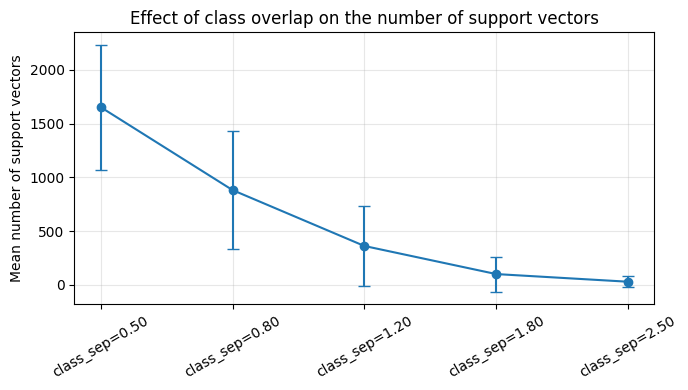

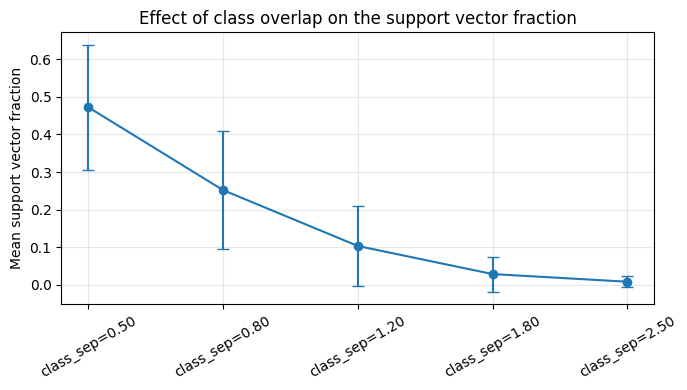

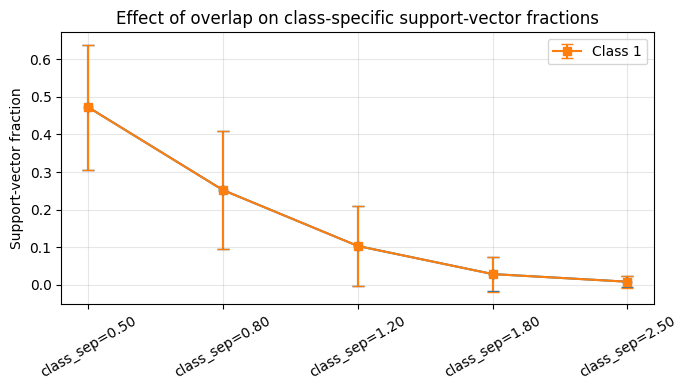

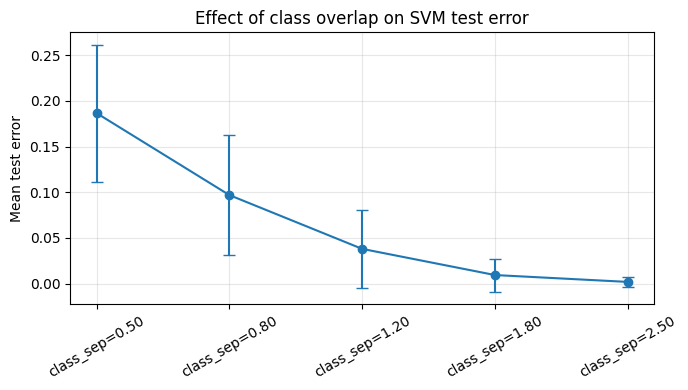

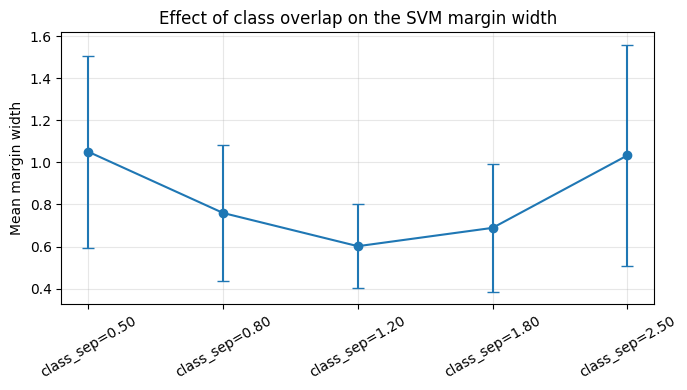

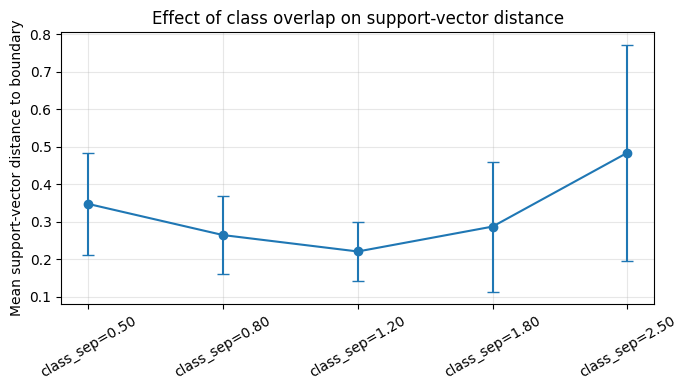

In [21]:
# Effect of class overlap.
plot_metric(summary, "overlap", "mean_n_support_total", "std_n_support_total",
            "Mean number of support vectors", "Effect of class overlap on the number of support vectors")
plot_metric(summary, "overlap", "mean_support_fraction", "std_support_fraction",
            "Mean support vector fraction", "Effect of class overlap on the support vector fraction")
plot_metric(summary, "overlap", "mean_support_rate_class_0", "std_support_rate_class_0", "Support-vector fraction",
            "Effect of overlap on class-specific support-vector fractions", second_mean_col="mean_support_rate_class_1",
            second_std_col="std_support_rate_class_1", first_label="Class 0", second_label="Class 1")
plot_metric(summary, "overlap", "mean_test_error", "std_test_error",
            "Mean test error", "Effect of class overlap on SVM test error")
plot_metric(summary, "overlap", "mean_margin_width", "std_margin_width",
            "Mean margin width", "Effect of class overlap on the SVM margin width")
plot_metric(summary, "overlap", "mean_support_distance", "std_support_distance", "Mean support-vector distance to boundary",
            "Effect of class overlap on support-vector distance")

**Interpretation of overlap plots.** Since smaller `class_sep` means stronger overlap, the left side of the plots corresponds to harder classification problems. When overlap increases, more points fall near the separating hyperplane or cross it. These points receive positive hinge loss or lie on the margin, so the SVM uses more support vectors. Test error also increases because the Bayes problem itself becomes more ambiguous. We see that the problem becomes geometrically simpler when the separation between the classes increases.

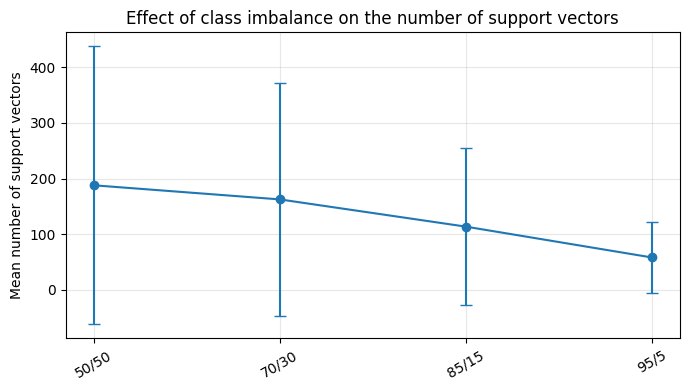

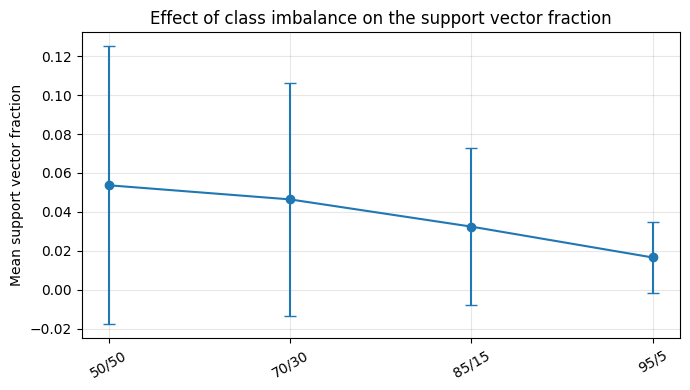

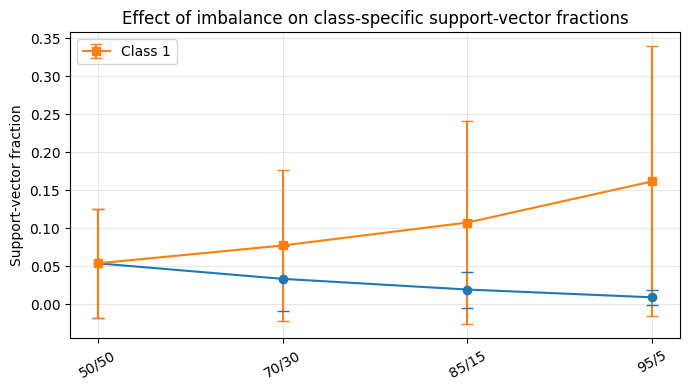

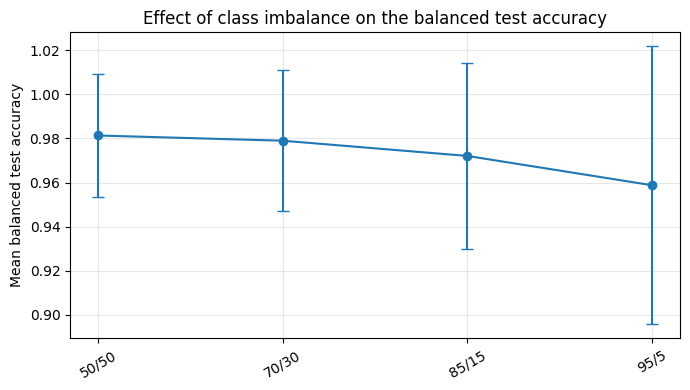

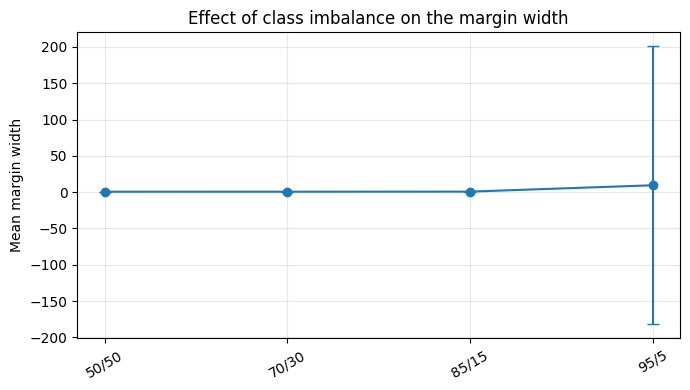

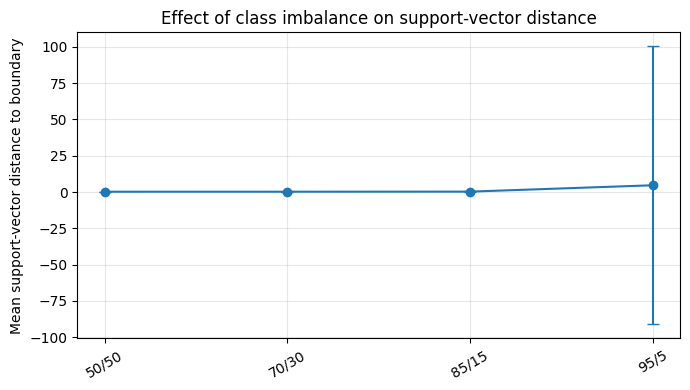

In [22]:
# Effect of class imbalance.
plot_metric(summary, "imbalance", "mean_n_support_total", "std_n_support_total",
            "Mean number of support vectors", "Effect of class imbalance on the number of support vectors")
plot_metric(summary, "imbalance", "mean_support_fraction", "std_support_fraction",
            "Mean support vector fraction", "Effect of class imbalance on the support vector fraction")
plot_metric(summary, "imbalance", "mean_support_rate_class_0", "std_support_rate_class_0", "Support-vector fraction",
            "Effect of imbalance on class-specific support-vector fractions", second_mean_col="mean_support_rate_class_1",
            second_std_col="std_support_rate_class_1", first_label="Class 0", second_label="Class 1")
plot_metric(summary, "imbalance", "mean_balanced_test_accuracy", "std_balanced_test_accuracy",
            "Mean balanced test accuracy", "Effect of class imbalance on the balanced test accuracy")
plot_metric(summary, "imbalance", "mean_margin_width", "std_margin_width",
            "Mean margin width", "Effect of class imbalance on the margin width")
plot_metric(summary, "imbalance", "mean_support_distance", "std_support_distance", "Mean support-vector distance to boundary",
            "Effect of class imbalance on support-vector distance")

**Interpretation of imbalance plots.** In imbalanced data, the total number of support vectors can decrease because one class contains very few points. However, the minority class may have a high support-vector rate, meaning a large fraction of minority points becomes geometrically important. Balanced accuracy is reported because ordinary accuracy can be misleading under class imbalance.

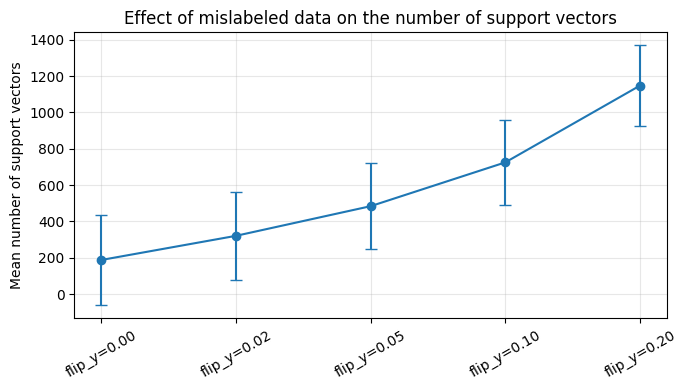

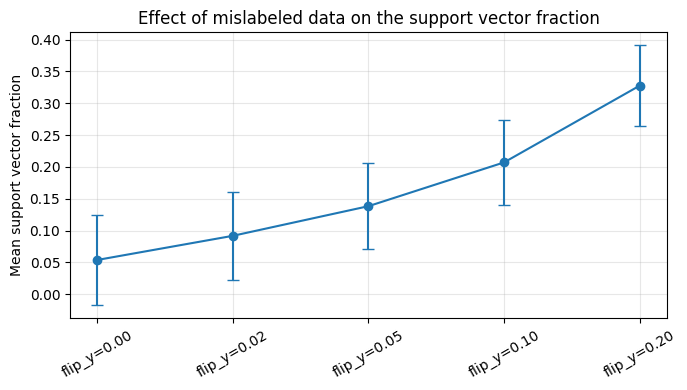

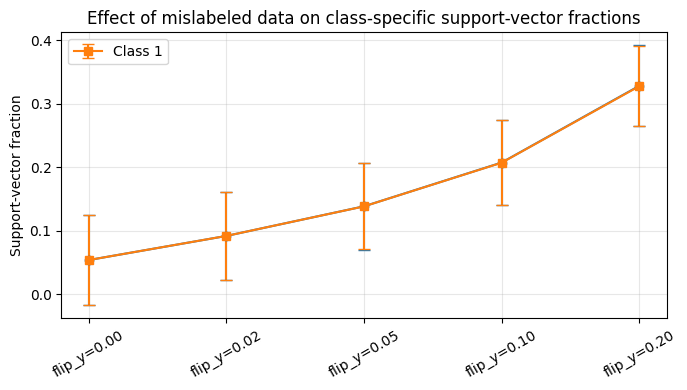

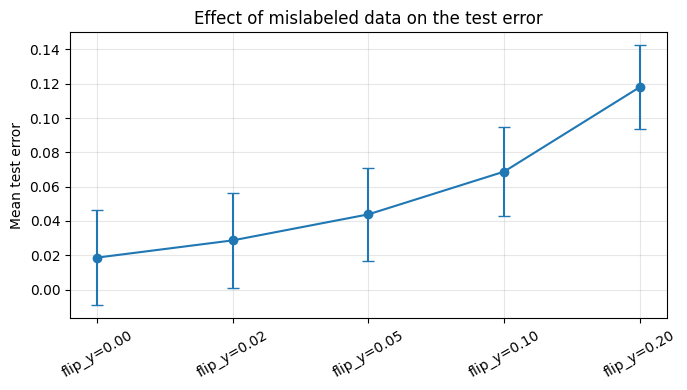

In [ ]:
# Effect of mislabeled data.
plot_metric(summary, "label_noise", "mean_n_support_total", "std_n_support_total",
            "Mean number of support vectors", "Effect of mislabeled data on the number of support vectors")
plot_metric(summary, "label_noise", "mean_support_fraction", "std_support_fraction",
            "Mean support vector fraction", "Effect of mislabeled data on the support vector fraction")
plot_metric(summary, "label_noise", "mean_support_rate_class_0", "std_support_rate_class_0", "Support-vector fraction",
            "Effect of mislabeled data on class-specific support-vector fractions", second_mean_col="mean_support_rate_class_1",
            second_std_col="std_support_rate_class_1", first_label="Class 0", second_label="Class 1")
plot_metric(summary, "label_noise", "mean_test_error", "std_test_error",
            "Mean test error", "Effect of mislabeled data on the test error")
plot_metric(summary, "label_noise", "mean_margin_width", "std_margin_width",
            "Mean margin width", "Effect of mislabeled data on the margin width")
plot_metric(summary, "label_noise", "mean_support_distance", "std_support_distance", "Mean support-vector distance to boundary",
            "Effect of mislabeled data on support-vector distance")

**Interpretation of label-noise plots.** Mislabeled observations often contradict the otherwise dominant class structure. Such points are likely to lie inside the margin or on the wrong side of the boundary, so they frequently become support vectors. Increasing label noise should therefore increase the support-vector fraction and test error, making the generalization harder. We might have expected noise to reduce the margin, but in soft-margin SVM, increasing noise shows tends to thicken the margin around the decision boundary. That means that the classifier accepts more violations raher thatn tightly fitting noisy points. This effect could be analyzed for different values of C.

## 6. Final conclusions :

The experiments support the theoretical interpretation of support vectors in soft-margin SVMs.

**Class overlap.** As overlap increases, a larger fraction of observations lies near the decision boundary or inside the margin. Consequently, the number and fraction of support vectors increase, and test error generally increases. Support vectors are spatially concentrated in the ambiguous region where classes mix.

**Class imbalance.** Class imbalance changes the distribution of support vectors across classes. The minority class may contribute fewer support vectors in absolute number because it has fewer samples, but a large fraction of minority observations can become support vectors. Therefore, support-vector counts should be interpreted together with class-specific support-vector rates.

**Mislabeled data.** Mislabeled observations create contradictory constraints. They frequently lie on the wrong side of the decision boundary or inside the margin and therefore often become support vectors. Increasing label noise tends to increase the support-vector fraction and degrade predictive performance.

**Conclusion.** In a soft-margin SVM, support vectors are not arbitrary training points and reflect ambiguity in the data. They are the observations with positive hinge loss or active margin constraints. More generally, they are the observations that determine the trade-off between margin maximization and empirical classification error. Overlap, imbalance, and label noise increase the number or importance of such critical observations because they make the classification problem geometrically harder.overlap thickens the boundary region, imbalance shifts the boundary, and mislabeled data introduces anomalous support vectors.

# Research question 3 (Denis)

### What is the impact of class imbalance on the performance? 

The research question is motivated in the context of binary classfication between signal and background, in which case background is over-dominating the signal. 

For instance, Gamma-ray Cherenkov telescopes data can be classified between the following two classes: gamma-rays (signal) and cosmic ray induced hadronic showers (background). 

Real data from the MAGIC gamma telescope is available on Kaggle. The idea is to use such dataset to potentially compare the performance between imbalanced classes and a balanced version (or something in those lines).


Denis



In [ ]:
# code for training the models etc 
df = pd.read_csv('telescope_data.csv')

print(f'Dataset Shape : {df.shape}')
print(f'Target Classes: {df["class"].unique()}')

# interpretation 

# visualization

In [ ]:
# code for visualization 

# Results and discussion

# Conclusion